# Laboratorio 4 Parte 2
## Avance de los ejercicios 1, 2 y 3

link del repo: https://github.com/Ninaswiftie09/Data_Science/tree/Laboratorio4_Parte2

## 1. Importaciones y conexión con el proyecto



In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from config import (
    DATASET_ML_PATH,
    LAGOS,
    MUESTRA_ML_POR_FECHA,
    NUBOSIDAD_OFICIAL,
    RANDOM_STATE,
    RESULTADOS_DIR,
    UMBRAL_CYANO_ALTO
)

from funciones import (
    construir_dataset_ml,
    graficar_distribucion_objetivo,
    graficar_eda_ml,
    resumir_dataset_ml
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

print("Proyecto:", project_root)
print("Dataset ML:", DATASET_ML_PATH)
print("Umbral de cianobacteria alta:", UMBRAL_CYANO_ALTO)
print("Máximo por fecha:", MUESTRA_ML_POR_FECHA)

Proyecto: c:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science
Dataset ML: C:\Users\ninan\OneDrive\Documentos\Escritorio\UVG\VIII SEMESTRE\Data Science\Data_Science\data\processed\dataset_ml_parte2.csv.gz
Umbral de cianobacteria alta: 0.05
Máximo por fecha: 30000


# Ejercicio 1. Preparación de los datos para Machine Learning

La Parte I dejó 3,460,152 píxeles válidos de agua entre los dos lagos. Atitlán aporta 3,052,034 y Amatitlán aporta 408,118. Para que el conjunto sea manejable y para que una fecha no domine solo por tener más píxeles, se toman hasta 30,000 observaciones por lago y fecha. El muestreo conserva la proporción original de la clase alta y baja dentro de cada fecha.

Con las 22 fechas disponibles el conjunto final contiene 660,000 observaciones. Cada fila conserva su longitud, latitud, fecha, lago, bandas espectrales, NDVI, NDWI e índice de cianobacteria.

## 1.1 Construcción del conjunto de datos

Se reutilizan los GeoTIFF descargados en la Parte I. La función aplica la misma máscara de agua y calidad que ya estaba implementada. También elimina valores no finitos antes de crear cada observación.

In [2]:
datos = construir_dataset_ml(
    lagos=LAGOS,
    nubosidad_oficial=NUBOSIDAD_OFICIAL,
    salida_csv=DATASET_ML_PATH,
    umbral_cyano=UMBRAL_CYANO_ALTO,
    max_observaciones_fecha=MUESTRA_ML_POR_FECHA,
    random_state=RANDOM_STATE,
    reutilizar=True
)

print("Forma del conjunto:", datos.shape)
datos.head()

Atitlán - 2025-01-18: 30,000 observaciones
Atitlán - 2025-04-13: 30,000 observaciones
Atitlán - 2025-05-13: 30,000 observaciones
Atitlán - 2025-07-17: 30,000 observaciones
Atitlán - 2025-11-21: 30,000 observaciones
Atitlán - 2025-12-29: 30,000 observaciones
Atitlán - 2026-02-12: 30,000 observaciones
Atitlán - 2026-03-24: 30,000 observaciones
Atitlán - 2026-04-13: 30,000 observaciones
Atitlán - 2026-04-28: 30,000 observaciones
Atitlán - 2026-07-22: 30,000 observaciones
Amatitlán - 2025-01-28: 30,000 observaciones
Amatitlán - 2025-04-15: 30,000 observaciones
Amatitlán - 2025-04-28: 30,000 observaciones
Amatitlán - 2025-11-24: 30,000 observaciones
Amatitlán - 2026-01-08: 30,000 observaciones
Amatitlán - 2026-02-02: 30,000 observaciones
Amatitlán - 2026-02-07: 30,000 observaciones
Amatitlán - 2026-03-29: 30,000 observaciones
Amatitlán - 2026-04-13: 30,000 observaciones
Amatitlán - 2026-04-28: 30,000 observaciones
Amatitlán - 2026-06-19: 30,000 observaciones
Conjunto de datos guardado en: C

,longitud,latitud,fecha,lago,B03,B04,B05,B06,B08,SCL,ndvi,ndwi,cyano,cyano_alta,nubosidad_pct,mes,dia_anio,mes_sin,mes_cos,dia_anio_sin,dia_anio_cos
0,-91.214362,14.736191,2025-01-18,Atitlán,0.0093,0.0017,0.0011,0.0018,0.0033,6,0.320000,0.476190,-0.000578,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
1,-91.192220,14.696073,2025-01-18,Atitlán,0.0092,0.0003,-0.0015,-0.0004,0.0016,6,0.684211,0.703704,-0.001251,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
2,-91.150258,14.673510,2025-01-18,Atitlán,0.0076,0.0004,0.0002,0.0009,0.0010,6,0.428571,0.767442,0.000246,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
3,-91.165204,14.729119,2025-01-18,Atitlán,0.0087,0.0003,-0.0006,-0.0005,0.0005,6,0.250000,0.891304,-0.000473,0,0.02,1,18,0.5,0.866025,0.304115,0.952635
4,-91.230941,14.684080,2025-01-18,Atitlán,0.0111,0.0010,0.0008,0.0005,0.0009,6,-0.052632,0.850000,0.000067,0,0.02,1,18,0.5,0.866025,0.304115,0.952635


## 1.2 Variables incluidas

El conjunto mantiene las coordenadas, la fecha, el lago, las bandas B03, B04, B05, B06 y B08, la clase SCL, NDVI, NDWI y el índice de cianobacteria. También conserva la nubosidad de la fecha y crea variables temporales cíclicas para usarlas después como predictores.

## 1.3 Limpieza aplicada

Se eliminan píxeles con NoData y valores no finitos. También se quitan sombras, nubes, cirros y nieve mediante SCL. Después se usa NDWI mayor que cero para mantener principalmente agua. Finalmente se exige que las bandas necesarias y los índices tengan valores válidos.

El muestreo se hace después de la limpieza. De esta forma cada fila del conjunto representa una observación válida y no se introducen valores artificiales para rellenar datos faltantes.

## 1.4 Cantidad de observaciones, tipos y valores faltantes

In [3]:
resumen_parte1 = pd.read_csv(
    RESULTADOS_DIR / "resumen_indices.csv",
    parse_dates=["fecha"]
)

print("Píxeles válidos antes del muestreo:", f"{resumen_parte1['pixeles_validos'].sum():,}")
print(resumen_parte1.groupby("lago")["pixeles_validos"].sum())
print("Observaciones esperadas después del muestreo:", len(LAGOS) * 11 * MUESTRA_ML_POR_FECHA)

Píxeles válidos antes del muestreo: 3,460,152
lago
Amatitlán     408118
Atitlán      3052034
Name: pixeles_validos, dtype: int64
Observaciones esperadas después del muestreo: 660000


In [4]:
resumen_ml = resumir_dataset_ml(datos)

print("Total de observaciones:", f"{resumen_ml['total']:,}")
print("\nObservaciones por lago")
display(resumen_ml["por_lago"])

print("Observaciones por fecha")
display(resumen_ml["por_fecha"])

print("Tipos y porcentaje de valores faltantes")
display(resumen_ml["faltantes"])

Total de observaciones: 660,000

Observaciones por lago


,lago,observaciones
0,Amatitlán,330000
1,Atitlán,330000


Observaciones por fecha


,lago,fecha,observaciones
0,Amatitlán,2025-01-28,30000
1,Amatitlán,2025-04-15,30000
2,Amatitlán,2025-04-28,30000
3,Amatitlán,2025-11-24,30000
4,Amatitlán,2026-01-08,30000
5,Amatitlán,2026-02-02,30000
6,Amatitlán,2026-02-07,30000
7,Amatitlán,2026-03-29,30000
8,Amatitlán,2026-04-13,30000
9,Amatitlán,2026-04-28,30000


Tipos y porcentaje de valores faltantes


,variable,tipo,faltantes_pct
0,longitud,float64,0.0
1,latitud,float64,0.0
2,fecha,datetime64[s],0.0
3,lago,object,0.0
4,B03,float32,0.0
5,B04,float32,0.0
6,B05,float32,0.0
7,B06,float32,0.0
8,B08,float32,0.0
9,SCL,int16,0.0


### Resultado esperado por lago

El límite de 30,000 observaciones por fecha deja 330,000 observaciones para Atitlán y 330,000 para Amatitlán. Esto evita que Atitlán domine el conjunto solo por tener una superficie mayor dentro de los rasters procesados.

## 1.5 Análisis exploratorio

Se revisan las distribuciones de B03, NDVI, NDWI y el índice de cianobacteria. También se muestran las observaciones geográficas de cada lago para comprobar que los puntos están distribuidos sobre el área de agua analizada.

,count,mean,std,min,25%,50%,75%,max
B03,660000.0,0.045454,0.080362,0.001000,0.016200,0.022900,0.054300,1.941800
ndvi,660000.0,-0.080779,0.225024,-0.991968,-0.161290,-0.055480,0.006342,0.977012
ndwi,660000.0,0.417589,0.212389,0.000089,0.264516,0.400000,0.558282,0.996441
cyano,660000.0,0.009402,0.016316,-0.498787,0.000393,0.002427,0.012727,0.719760
longitud,660000.0,-90.882212,0.314816,-91.327001,-91.195402,-90.857015,-90.569407,-90.512020
latitud,660000.0,14.577328,0.121629,14.411766,14.460575,14.544830,14.698587,14.750372
nubosidad_pct,660000.0,2.179091,2.970539,0.010000,0.060000,0.655000,3.570000,13.000000


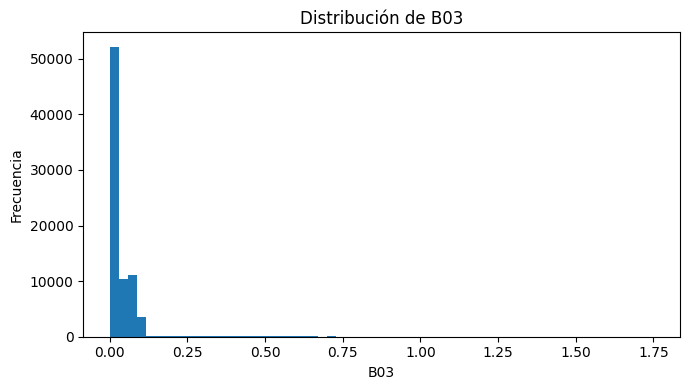

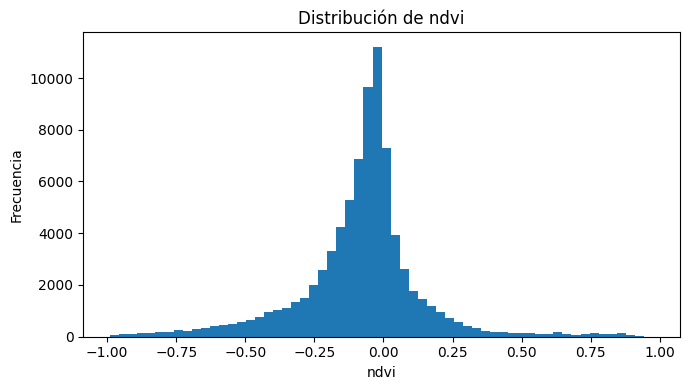

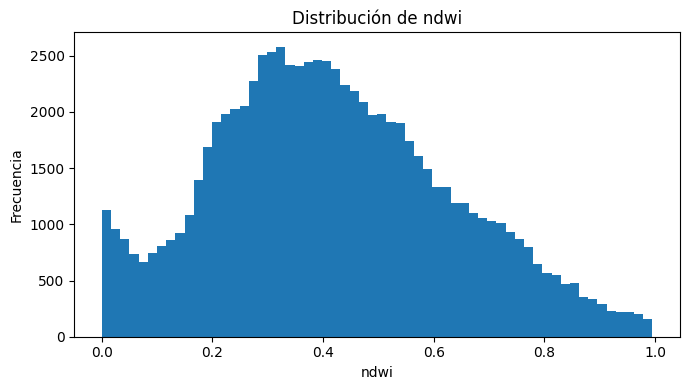

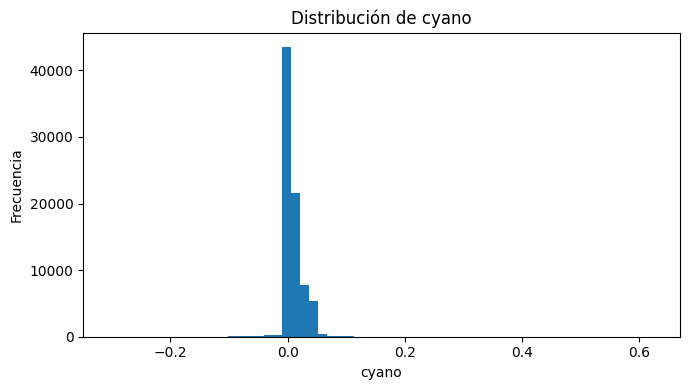

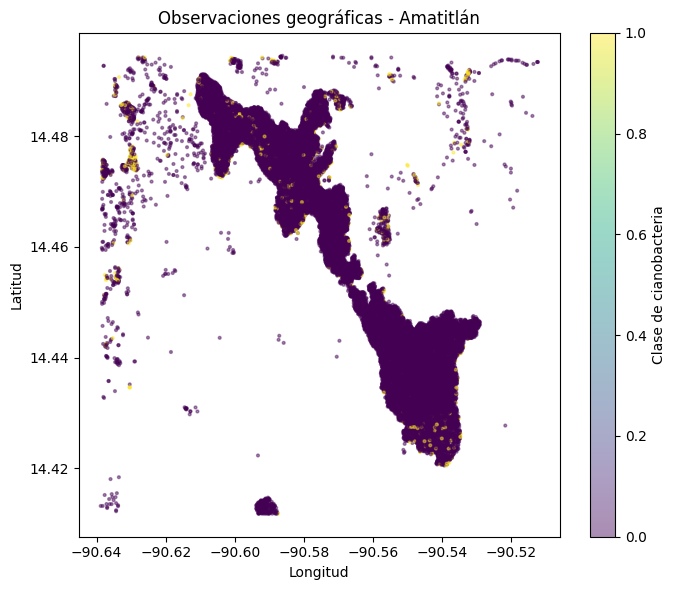

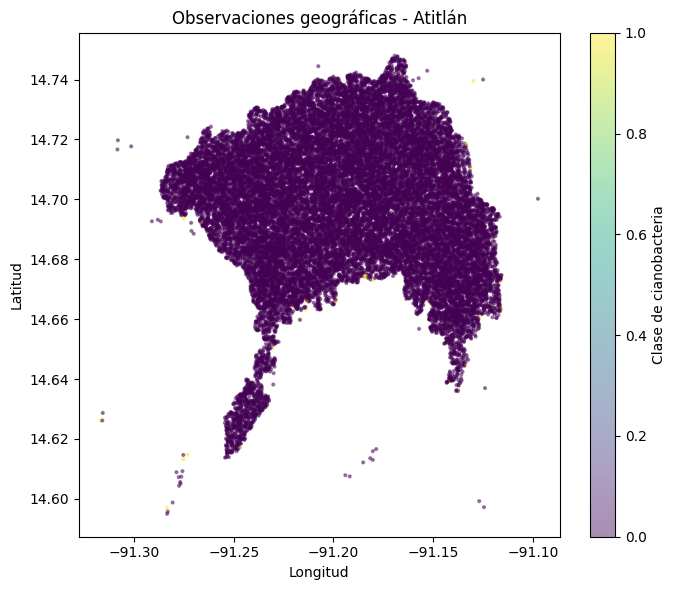

In [5]:
columnas_eda = [
    "B03",
    "ndvi",
    "ndwi",
    "cyano",
    "longitud",
    "latitud",
    "nubosidad_pct"
]

display(datos[columnas_eda].describe().T)

graficar_eda_ml(datos)

## 1.6 Decisiones de preparación

Se mantuvo la resolución y las fechas de la Parte I para que los dos laboratorios sean comparables. No se descargaron nuevas escenas. Se reutilizó la máscara de calidad con SCL y la máscara de agua con NDWI.

El muestreo por fecha reduce el tamaño del conjunto sin dejar fechas con muy poca representación. Además se conserva la proporción de la variable respuesta dentro de cada fecha. Esto es útil porque la clase alta es poco frecuente.

# Ejercicio 2. Construcción de la variable respuesta

La variable cyano_alta usa dos clases.

0 significa ausencia o señal baja.

1 significa señal alta compatible con una floración de mayor intensidad.

## 2.1 Punto de corte

Se usa el mismo Bloom Index de la Parte I. El índice toma el máximo entre MCI y FAI usando B04, B05, B06 y B08. La clase alta se define cuando cyano es mayor que 0.05.

El valor 0.05 se toma del script Maximum Peak Height Bloom Index de Sentinel Hub y CyanoLakes. Ese script usa 0.05 como nivel de referencia para valores asociados con algas flotantes. Este índice no mide directamente concentración de células ni riesgo sanitario. Por eso el corte se usa como una separación espectral operativa entre señal baja y señal alta.

In [6]:
datos["cyano_alta"] = (
    datos["cyano"] > UMBRAL_CYANO_ALTO
).astype("int8")

datos[["cyano", "cyano_alta"]].head()

,cyano,cyano_alta
0,-0.000578,0
1,-0.001251,0
2,0.000246,0
3,-0.000473,0
4,0.000067,0


## 2.2 Justificación científica

Matthews, Bernard y Robertson desarrollaron el enfoque Maximum Peak Height para detectar condiciones tróficas, dominancia de cianobacteria y acumulaciones superficiales en aguas interiores. El script de Sentinel Hub adapta ese enfoque a Sentinel-2 y combina MCI con FAI.

La literatura también muestra que un único umbral espectral no es universal para todos los lagos. Las condiciones atmosféricas, la calidad del agua y la geometría de observación pueden cambiar el valor óptimo. Por eso 0.05 se usa aquí como criterio reproducible para este laboratorio y no como una concentración ambiental universal.

## 2.3 Distribución de la respuesta

Distribución global


,cyano_alta,observaciones,porcentaje
0,0,651969,98.783182
1,1,8031,1.216818


Distribución por lago


,lago,cyano_alta,observaciones,porcentaje
0,Amatitlán,0,322415,97.701515
1,Amatitlán,1,7585,2.298485
2,Atitlán,0,329554,99.864848
3,Atitlán,1,446,0.135152


Distribución por fecha


,lago,fecha,cyano_alta,observaciones,porcentaje
0,Amatitlán,2025-01-28,0,29630,98.766667
1,Amatitlán,2025-01-28,1,370,1.233333
2,Amatitlán,2025-04-15,0,29675,98.916667
3,Amatitlán,2025-04-15,1,325,1.083333
4,Amatitlán,2025-04-28,0,29676,98.920000
5,Amatitlán,2025-04-28,1,324,1.080000
6,Amatitlán,2025-11-24,0,29557,98.523333
7,Amatitlán,2025-11-24,1,443,1.476667
8,Amatitlán,2026-01-08,0,29622,98.740000
9,Amatitlán,2026-01-08,1,378,1.260000


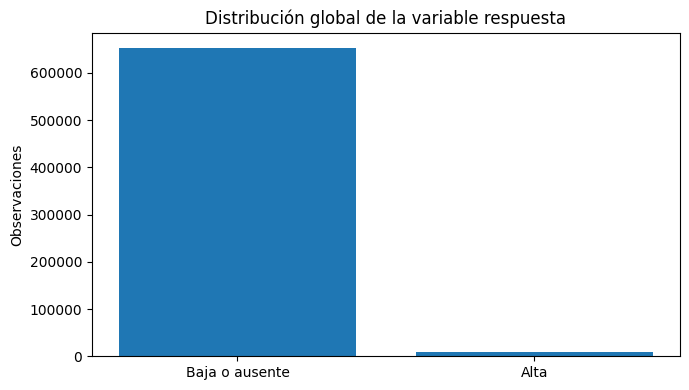

In [7]:
respuesta_global = (
    datos["cyano_alta"]
    .value_counts()
    .sort_index()
    .rename_axis("cyano_alta")
    .reset_index(name="observaciones")
)

respuesta_global["porcentaje"] = (
    respuesta_global["observaciones"]
    / len(datos)
    * 100
)

print("Distribución global")
display(respuesta_global)

respuesta_lago = (
    datos
    .groupby(["lago", "cyano_alta"])
    .size()
    .rename("observaciones")
    .reset_index()
)

respuesta_lago["porcentaje"] = (
    respuesta_lago["observaciones"]
    / respuesta_lago.groupby("lago")["observaciones"].transform("sum")
    * 100
)

print("Distribución por lago")
display(respuesta_lago)

respuesta_fecha = (
    datos
    .groupby(["lago", "fecha", "cyano_alta"])
    .size()
    .rename("observaciones")
    .reset_index()
)

respuesta_fecha["porcentaje"] = (
    respuesta_fecha["observaciones"]
    / respuesta_fecha.groupby(["lago", "fecha"])["observaciones"].transform("sum")
    * 100
)

print("Distribución por fecha")
display(respuesta_fecha)

graficar_distribucion_objetivo(datos)

### Resultado del desbalance

Con el muestreo definido se esperan 8,031 observaciones de clase alta de un total de 660,000. Esto representa aproximadamente 1.22 por ciento. La clase alta sigue siendo minoritaria.

En Atitlán la clase alta representa cerca de 0.14 por ciento. En Amatitlán representa cerca de 2.30 por ciento. La diferencia entre los lagos es grande y coincide con lo observado en la Parte I.

## 2.4 Consecuencias del desbalance

El desbalance puede hacer que un modelo aprenda a predecir casi siempre la clase baja y aun así obtenga una Accuracy alta. En las siguientes etapas será importante revisar Recall y F1 para la clase alta. También se podrá evaluar el uso de pesos de clase durante el entrenamiento.

Desde el punto de vista ambiental, no detectar una zona con señal alta puede ser más grave que generar una alerta adicional. Por eso más adelante será importante vigilar especialmente el Recall de la clase alta.

## 2.5 Variables que no pueden usarse como predictoras

B04, B05, B06 y B08 no se usan como predictores porque forman directamente el Bloom Index que crea la variable respuesta.

NDVI y NDWI tampoco se usan en el conjunto base de predictores porque dependen de B04 y B08. Usarlos podría introducir información indirecta del mismo conjunto de bandas que construye la respuesta.

La variable cyano tampoco puede usarse porque es la variable continua de la que sale cyano_alta. SCL se conserva para control de calidad, pero no se usa como predictor.

# Ejercicio 3. Selección y construcción de variables predictoras

El conjunto base usa variables espaciales, una banda espectral independiente de la fórmula del Bloom Index y variables temporales. El nombre del lago se conserva como metadato para separar experimentos, pero no se incluye en el conjunto base. Esto permitirá evaluar más adelante la generalización entre lagos con la misma lista de predictores.

In [8]:
PREDICTORES = [
    "longitud",
    "latitud",
    "B03",
    "nubosidad_pct",
    "mes_sin",
    "mes_cos",
    "dia_anio_sin",
    "dia_anio_cos"
]

EXCLUIDAS_POR_FUGA = [
    "B04",
    "B05",
    "B06",
    "B08",
    "ndvi",
    "ndwi",
    "cyano"
]

print("Predictoras:", PREDICTORES)
print("Excluidas por fuga:", EXCLUIDAS_POR_FUGA)

Predictoras: ['longitud', 'latitud', 'B03', 'nubosidad_pct', 'mes_sin', 'mes_cos', 'dia_anio_sin', 'dia_anio_cos']
Excluidas por fuga: ['B04', 'B05', 'B06', 'B08', 'ndvi', 'ndwi', 'cyano']


## 3.1 Variables predictoras

Longitud y latitud representan la posición espacial de cada observación. Pueden ayudar a detectar zonas del lago que repiten condiciones parecidas.

B03 representa reflectancia en la banda verde. No participa en la fórmula usada para crear cyano y conserva información espectral adicional.

Nubosidad_pct representa la nubosidad reportada para la fecha. Se mantiene como información de contexto de cada escena.

Mes y día del año se transforman con seno y coseno. Esto permite representar el ciclo anual sin tratar diciembre y enero como meses muy lejanos.

In [9]:
tabla_predictoras = pd.DataFrame([
    ["longitud", "Espacial", "Ubicación este-oeste de la observación"],
    ["latitud", "Espacial", "Ubicación norte-sur de la observación"],
    ["B03", "Banda espectral", "Reflectancia verde independiente de la fórmula de cyano"],
    ["nubosidad_pct", "Contexto de la escena", "Nubosidad reportada para la fecha"],
    ["mes_sin", "Temporal", "Componente cíclico del mes"],
    ["mes_cos", "Temporal", "Componente cíclico del mes"],
    ["dia_anio_sin", "Temporal", "Componente cíclico del día del año"],
    ["dia_anio_cos", "Temporal", "Componente cíclico del día del año"]
], columns=["variable", "tipo", "descripcion"])

tabla_predictoras

,variable,tipo,descripcion
0,longitud,Espacial,Ubicación este-oeste de la observación
1,latitud,Espacial,Ubicación norte-sur de la observación
2,B03,Banda espectral,Reflectancia verde independiente de la fórmula...
3,nubosidad_pct,Contexto de la escena,Nubosidad reportada para la fecha
4,mes_sin,Temporal,Componente cíclico del mes
5,mes_cos,Temporal,Componente cíclico del mes
6,dia_anio_sin,Temporal,Componente cíclico del día del año
7,dia_anio_cos,Temporal,Componente cíclico del día del año


## 3.2 Ingeniería de características

Las únicas variables nuevas son las transformaciones cíclicas de mes y día del año. Se construyen a partir de la fecha que ya estaba disponible. No se agregan nuevas imágenes ni nuevas bandas.

Esta transformación puede ayudar a representar cambios estacionales sin introducir un salto artificial entre el final y el inicio del año.

In [10]:
correlacion_predictoras = datos[PREDICTORES].corr(numeric_only=True)
correlacion_predictoras

,longitud,latitud,B03,nubosidad_pct,mes_sin,mes_cos,dia_anio_sin,dia_anio_cos
longitud,1.000000,-0.983027,0.291192,-0.092686,0.231523,0.093266,0.154646,0.120988
latitud,-0.983027,1.000000,-0.292055,0.089826,-0.229034,-0.087205,-0.154905,-0.114435
B03,0.291192,-0.292055,1.000000,0.090278,0.102337,-0.153117,0.136959,-0.147248
nubosidad_pct,-0.092686,0.089826,0.090278,1.000000,-0.358019,-0.472332,-0.204069,-0.555626
mes_sin,0.231523,-0.229034,0.102337,-0.358019,1.000000,-0.090283,0.946891,0.069446
mes_cos,0.093266,-0.087205,-0.153117,-0.472332,-0.090283,1.000000,-0.366586,0.978551
dia_anio_sin,0.154646,-0.154905,0.136959,-0.204069,0.946891,-0.366586,1.000000,-0.217131
dia_anio_cos,0.120988,-0.114435,-0.147248,-0.555626,0.069446,0.978551,-0.217131,1.000000


# Resultados principales del avance

Se parte de 3,460,152 píxeles válidos obtenidos en la Parte I y se construye un conjunto de 660,000 observaciones con representación uniforme por fecha y lago.

La variable respuesta usa 0.05 como corte operativo para señal alta. La clase alta representa cerca de 1.22 por ciento del conjunto y existe un desbalance fuerte.

Para evitar fuga de información no se usan B04, B05, B06, B08, NDVI, NDWI ni cyano como predictores. El conjunto base queda formado por ubicación, B03, nubosidad y variables temporales cíclicas.

Este conjunto queda listo para construir los modelos de la siguiente etapa sin volver a procesar la Parte I desde cero.

# Referencias

Sentinel Hub. Maximum Peak Height Bloom Index. Custom scripts for Sentinel-2.
https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/maximum_peak_height_bloom_index/

Matthews, M. W., Bernard, S. y Robertson, L. 2012. An algorithm for detecting trophic status, cyanobacterial dominance, surface scums and floating vegetation in inland and coastal waters. Remote Sensing of Environment, 124, 637 a 652.

Gower, J., King, S. y Goncalves, P. 2008. Global monitoring of plankton blooms using MERIS MCI. International Journal of Remote Sensing, 29, 6209 a 6216.

Hu, C. 2009. A novel ocean color index to detect floating algae in the global oceans. Remote Sensing of Environment, 113, 2118 a 2129.